In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.inspection import PartialDependenceDisplay

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Root:", PROJECT_ROOT)
print("Task 10 environment ready!")

Project Root: /home/akash/Projects/Altrodav
Task 10 environment ready!


In [3]:
from src.data import load_data

df = load_data()

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

print("Training Set  :", X_train.shape)
print("Validation Set:", X_val.shape)
print("Test Set      :", X_test.shape)

Training Set  : (105, 4)
Validation Set: (22, 4)
Test Set      : (23, 4)


In [5]:
baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

baseline_model.fit(X_train, y_train)

baseline_val_pred = baseline_model.predict(X_val)

baseline_val_accuracy = accuracy_score(
    y_val,
    baseline_val_pred
)

print(f"Baseline Validation Accuracy: {baseline_val_accuracy:.4f}")

Baseline Validation Accuracy: 0.8636


In [6]:
gb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_val_pred = gb_model.predict(X_val)

gb_val_accuracy = accuracy_score(
    y_val,
    gb_val_pred
)

print(f"Gradient Boosting Validation Accuracy: {gb_val_accuracy:.4f}")

Gradient Boosting Validation Accuracy: 0.9091


In [7]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Validation Accuracy": [
        baseline_val_accuracy,
        gb_val_accuracy
    ]
})

comparison["Lift"] = (
    comparison["Validation Accuracy"]
    - baseline_val_accuracy
)

display(comparison)

print("\n========== VALIDATION COMPARISON ==========")
print(f"Logistic Regression : {baseline_val_accuracy:.4f}")
print(f"Gradient Boosting   : {gb_val_accuracy:.4f}")
print(f"Validation Lift     : {gb_val_accuracy - baseline_val_accuracy:+.4f}")

,Model,Validation Accuracy,Lift
0,Logistic Regression,0.863636,0.000000
1,Gradient Boosting,0.909091,0.045455



========== VALIDATION COMPARISON ==========
Logistic Regression : 0.8636
Gradient Boosting   : 0.9091
Validation Lift     : +0.0455


In [8]:
baseline_precision = precision_score(
    y_val,
    baseline_val_pred,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_val,
    baseline_val_pred,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_val,
    baseline_val_pred,
    average="weighted",
    zero_division=0
)

gb_precision = precision_score(
    y_val,
    gb_val_pred,
    average="weighted",
    zero_division=0
)

gb_recall = recall_score(
    y_val,
    gb_val_pred,
    average="weighted",
    zero_division=0
)

gb_f1 = f1_score(
    y_val,
    gb_val_pred,
    average="weighted",
    zero_division=0
)

metrics_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Accuracy": [
        baseline_val_accuracy,
        gb_val_accuracy
    ],
    "Precision": [
        baseline_precision,
        gb_precision
    ],
    "Recall": [
        baseline_recall,
        gb_recall
    ],
    "F1 Score": [
        baseline_f1,
        gb_f1
    ]
})

display(metrics_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.863636,0.867424,0.863636,0.862937
1,Gradient Boosting,0.909091,0.909091,0.909091,0.909091


In [9]:
baseline_train_pred = baseline_model.predict(X_train)
gb_train_pred = gb_model.predict(X_train)

baseline_train_accuracy = accuracy_score(
    y_train,
    baseline_train_pred
)

gb_train_accuracy = accuracy_score(
    y_train,
    gb_train_pred
)

overfitting_check = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Training Accuracy": [
        baseline_train_accuracy,
        gb_train_accuracy
    ],
    "Validation Accuracy": [
        baseline_val_accuracy,
        gb_val_accuracy
    ],
    "Train-Val Gap": [
        baseline_train_accuracy - baseline_val_accuracy,
        gb_train_accuracy - gb_val_accuracy
    ]
})

display(overfitting_check)

print("\n========== OVERFITTING CHECK ==========")

print(
    f"Logistic Regression gap: "
    f"{baseline_train_accuracy - baseline_val_accuracy:.4f}"
)

print(
    f"Gradient Boosting gap: "
    f"{gb_train_accuracy - gb_val_accuracy:.4f}"
)

,Model,Training Accuracy,Validation Accuracy,Train-Val Gap
0,Logistic Regression,0.980952,0.863636,0.117316
1,Gradient Boosting,1.000000,0.909091,0.090909



========== OVERFITTING CHECK ==========
Logistic Regression gap: 0.1173
Gradient Boosting gap: 0.0909


In [10]:
baseline_test_pred = baseline_model.predict(X_test)
gb_test_pred = gb_model.predict(X_test)

baseline_test_accuracy = accuracy_score(
    y_test,
    baseline_test_pred
)

gb_test_accuracy = accuracy_score(
    y_test,
    gb_test_pred
)

test_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Test Accuracy": [
        baseline_test_accuracy,
        gb_test_accuracy
    ],
    "Test Lift": [
        0,
        gb_test_accuracy - baseline_test_accuracy
    ]
})

display(test_comparison)

print("\n========== FINAL TEST COMPARISON ==========")
print(f"Logistic Regression Test Accuracy : {baseline_test_accuracy:.4f}")
print(f"Gradient Boosting Test Accuracy   : {gb_test_accuracy:.4f}")
print(f"Test Accuracy Lift                : "
      f"{gb_test_accuracy - baseline_test_accuracy:+.4f}")

,Model,Test Accuracy,Test Lift
0,Logistic Regression,0.956522,0.000000
1,Gradient Boosting,0.913043,-0.043478



========== FINAL TEST COMPARISON ==========
Logistic Regression Test Accuracy : 0.9565
Gradient Boosting Test Accuracy   : 0.9130
Test Accuracy Lift                : -0.0435


,Feature,Importance
3,petal width (cm),0.654573
2,petal length (cm),0.333371
0,sepal length (cm),0.006347
1,sepal width (cm),0.005708


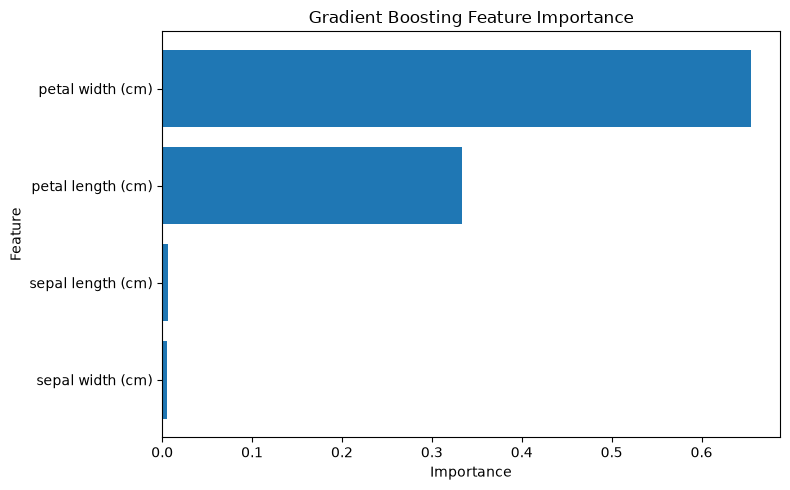

In [11]:
feature_names = X_train.columns.tolist()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.named_steps["model"].feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

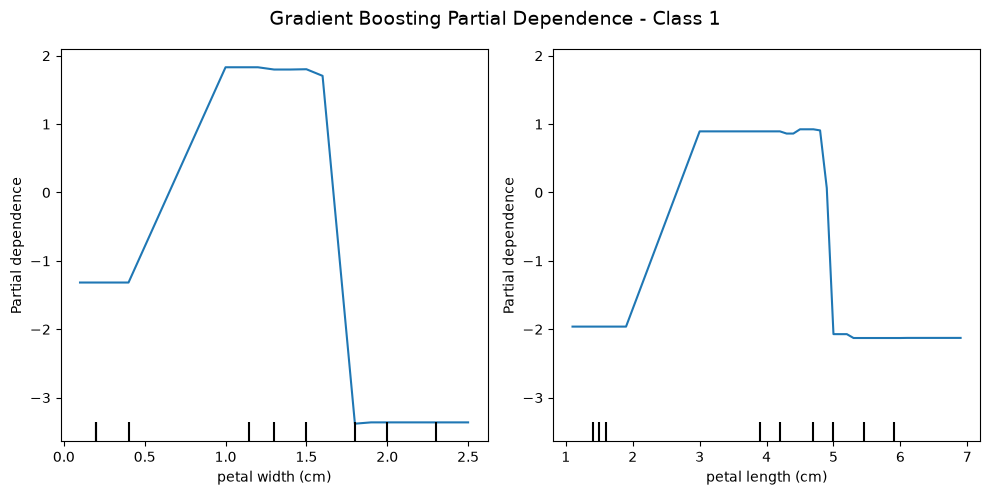

In [13]:
# Transform the training data using the fitted imputer
X_train_imputed = gb_model.named_steps["imputer"].transform(X_train)

# Get the fitted Gradient Boosting model
gb_estimator = gb_model.named_steps["model"]

# Select the two most important features
top_features = feature_importance["Feature"].head(2).tolist()

top_feature_indices = [
    feature_names.index(feature)
    for feature in top_features
]

fig, ax = plt.subplots(
    figsize=(10, 5),
    ncols=2
)

PartialDependenceDisplay.from_estimator(
    gb_estimator,
    X_train_imputed,
    features=top_feature_indices,
    feature_names=feature_names,
    target=1,              # Analyze class 1
    ax=ax
)

fig.suptitle(
    "Gradient Boosting Partial Dependence - Class 1",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [14]:
test_lift = gb_test_accuracy - baseline_test_accuracy

if test_lift > 0:
    decision = "Gradient Boosting provides measurable improvement and justifies the added complexity."
elif test_lift == 0:
    decision = "Gradient Boosting provides no measurable improvement, so the simpler Logistic Regression is preferred."
else:
    decision = "Gradient Boosting performs worse on unseen data, so the simpler Logistic Regression is preferred."

print("========== TASK 10 MODEL DECISION ==========")
print(f"Baseline Model          : Logistic Regression")
print(f"Baseline Test Accuracy  : {baseline_test_accuracy:.4f}")
print(f"Non-linear Model        : Gradient Boosting")
print(f"Gradient Boosting Test  : {gb_test_accuracy:.4f}")
print(f"Test Accuracy Lift      : {test_lift:+.4f}")
print()
print("Decision:")
print(decision)

========== TASK 10 MODEL DECISION ==========
Baseline Model          : Logistic Regression
Baseline Test Accuracy  : 0.9565
Non-linear Model        : Gradient Boosting
Gradient Boosting Test  : 0.9130
Test Accuracy Lift      : -0.0435

Decision:
Gradient Boosting performs worse on unseen data, so the simpler Logistic Regression is preferred.


In [15]:
import os

PROJECT_ROOT = os.path.abspath("..")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")

os.makedirs(LOG_DIR, exist_ok=True)

task10_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Validation Accuracy": [
        baseline_val_accuracy,
        gb_val_accuracy
    ],
    "Test Accuracy": [
        baseline_test_accuracy,
        gb_test_accuracy
    ],
    "Test Lift": [
        0.0,
        gb_test_accuracy - baseline_test_accuracy
    ],
    "Training Accuracy": [
        baseline_train_accuracy,
        gb_train_accuracy
    ],
    "Train_Validation_Gap": [
        baseline_train_accuracy - baseline_val_accuracy,
        gb_train_accuracy - gb_val_accuracy
    ]
})

results_path = os.path.join(
    LOG_DIR,
    "task10_complex_relationships_results.csv"
)

task10_results.to_csv(
    results_path,
    index=False
)

print("Task 10 results saved successfully!")
print("File:", results_path)

display(task10_results)

Task 10 results saved successfully!
File: /home/akash/Projects/Altrodav/logs/task10_complex_relationships_results.csv


,Model,Validation Accuracy,Test Accuracy,Test Lift,Training Accuracy,Train_Validation_Gap
0,Logistic Regression,0.863636,0.956522,0.000000,0.980952,0.117316
1,Gradient Boosting,0.909091,0.913043,-0.043478,1.000000,0.090909


In [16]:
print("=" * 55)
print("        TASK 10 — COMPLEX RELATIONSHIPS SUMMARY")
print("=" * 55)

print(f"Baseline Model              : Logistic Regression")
print(f"Baseline Validation Accuracy: {baseline_val_accuracy:.4f}")
print(f"Baseline Test Accuracy      : {baseline_test_accuracy:.4f}")

print()

print(f"Non-linear Model             : Gradient Boosting")
print(f"GB Validation Accuracy       : {gb_val_accuracy:.4f}")
print(f"GB Test Accuracy             : {gb_test_accuracy:.4f}")

print()

print(f"Test Accuracy Lift           : {test_lift:+.4f}")
print(f"GB Train-Validation Gap      : "
      f"{gb_train_accuracy - gb_val_accuracy:.4f}")

print()

print("Feature Importance Analysis  : Completed")
print("Partial Dependence Analysis  : Completed")
print("Overfitting Check            : Completed")
print("Test Set Evaluation          : Completed")
print("Results Artifact             : Saved")

print()

if test_lift > 0:
    print("FINAL DECISION:")
    print("Gradient Boosting provides measurable improvement.")
    print("The additional model complexity is justified.")
else:
    print("FINAL DECISION:")
    print("Logistic Regression is preferred.")
    print("Gradient Boosting did not provide sufficient improvement")
    print("on the unseen test set to justify its added complexity.")

print()
print("Task 10 Completed Successfully!")

        TASK 10 — COMPLEX RELATIONSHIPS SUMMARY
Baseline Model              : Logistic Regression
Baseline Validation Accuracy: 0.8636
Baseline Test Accuracy      : 0.9565

Non-linear Model             : Gradient Boosting
GB Validation Accuracy       : 0.9091
GB Test Accuracy             : 0.9130

Test Accuracy Lift           : -0.0435
GB Train-Validation Gap      : 0.0909

Feature Importance Analysis  : Completed
Partial Dependence Analysis  : Completed
Overfitting Check            : Completed
Test Set Evaluation          : Completed
Results Artifact             : Saved

FINAL DECISION:
Logistic Regression is preferred.
Gradient Boosting did not provide sufficient improvement
on the unseen test set to justify its added complexity.

Task 10 Completed Successfully!
